<a href="https://colab.research.google.com/github/ancestor9/mathematics-for-machine-learning/blob/main/scripts/w4_loss_function.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sympy as sp

# 1. 기호 변수 및 데이터 정의
w, b = sp.symbols('w b')
x_vals = [1, 2, 3, 4, 5]
y_vals = [2.1, 3.9, 6.2, 8.1, 10.1]
n = len(x_vals)

# 2. 손실 함수 (MSE) 수식화
loss = 0
for i in range(n):
    prediction = w * x_vals[i] + b
    loss += (prediction - y_vals[i])**2

loss = loss / n

# 3. 기울기(w)와 절편(b)에 대한 편미분
diff_w = sp.diff(loss, w)
diff_b = sp.diff(loss, b)

print(f"w에 대한 미분식: {diff_w}")
print(f"b에 대한 미분식: {diff_b}")

# 4. 미분값이 0이 되는 연립 방정식 풀이
solution = sp.solve((diff_w, diff_b), (w, b))

print("-" * 30)
print(f"최적의 기울기 (w): {solution[w]:.4f}")
print(f"최적의 절편 (b): {solution[b]:.4f}")

w에 대한 미분식: 6*b + 22*w - 44.56
b에 대한 미분식: 2*b + 6*w - 12.16
------------------------------
최적의 기울기 (w): 2.0200
최적의 절편 (b): 0.0200


In [2]:
diff_w

6*b + 22*w - 44.56

In [3]:
diff_b

2*b + 6*w - 12.16

In [5]:
import numpy as np

# Equations are:
# diff_w = 22*w + 6*b - 44.56 = 0  =>  22*w + 6*b = 44.56
# diff_b = 6*w + 2*b - 12.16 = 0  =>   6*w + 2*b = 12.16

# Define the coefficient matrix A
A = np.array([[22, 6],
              [6, 2]])

# Define the constant vector B
B = np.array([[44.56],
              [12.16]])

# Calculate the inverse of A
A_inv = np.linalg.inv(A)

# Solve for x (w, b) using x = A_inv * B
solution_matrix = np.dot(A_inv, B)

w_inv = solution_matrix[0][0]
b_inv = solution_matrix[1][0]

print(f"역행렬을 이용한 최적의 기울기 (w): {w_inv:.4f}")
print(f"역행렬을 이용한 최적의 절편 (b): {b_inv:.4f}")

역행렬을 이용한 최적의 기울기 (w): 2.0200
역행렬을 이용한 최적의 절편 (b): 0.0200


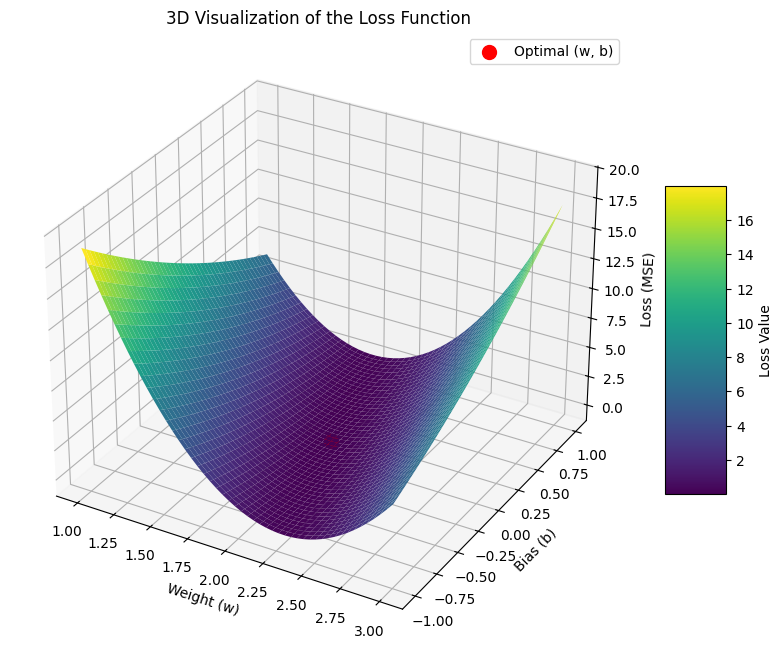

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Convert the symbolic loss function to a numerical function
# The 'loss' variable is available from cell wA9bEpN5Sxsl
loss_func = sp.lambdify((w, b), loss, 'numpy')

# Create a meshgrid for w and b values
w_vals = np.linspace(1, 3, 50) # Range for w, centered around the optimal value
b_vals = np.linspace(-1, 1, 50) # Range for b, centered around the optimal value
W, B = np.meshgrid(w_vals, b_vals)

# Calculate loss for each combination of W and B
Z = loss_func(W, B)

# Create the 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the surface
surface = ax.plot_surface(W, B, Z, cmap='viridis', edgecolor='none')

# Add labels and title
ax.set_xlabel('Weight (w)')
ax.set_ylabel('Bias (b)')
ax.set_zlabel('Loss (MSE)')
ax.set_title('3D Visualization of the Loss Function')

# Add a color bar which maps values to colors
fig.colorbar(surface, shrink=0.5, aspect=5, label='Loss Value')

# Highlight the minimum loss point
# Convert sympy.Float objects to standard floats for matplotlib
optimal_w = float(solution[w])
optimal_b = float(solution[b])
optimal_loss = float(loss_func(optimal_w, optimal_b))
ax.scatter(optimal_w, optimal_b, optimal_loss, color='red', s=100, label='Optimal (w, b)', marker='o', depthshade=True)
ax.legend()

plt.show()

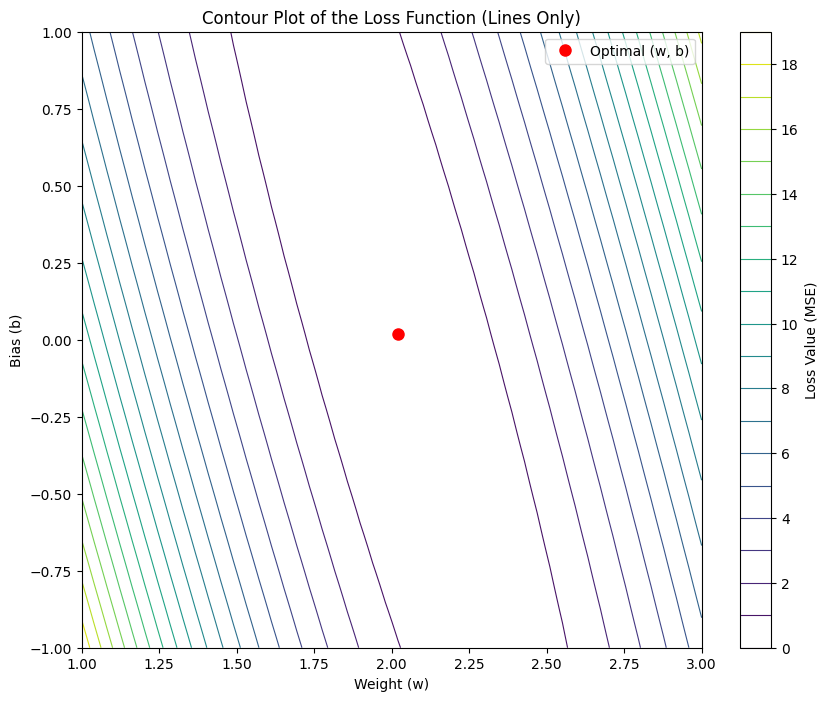

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# W, B, Z are available from the previous 3D plot generation (cell 027f7b7a)
# If running this cell independently, ensure W, B, Z are defined:
# loss_func = sp.lambdify((w, b), loss, 'numpy') # Make sure sp, w, b, loss are defined
# w_vals = np.linspace(1, 3, 50)
# b_vals = np.linspace(-1, 1, 50)
# W, B = np.meshgrid(w_vals, b_vals)
# Z = loss_func(W, B)

fig_contour, ax_contour = plt.subplots(figsize=(10, 8))

# Create a contour plot with lines only, no filling, and apply a colormap
contour = ax_contour.contour(W, B, Z, levels=20, cmap='viridis', linewidths=0.8)

# Add a color bar (optional for lines, but can show level values)
fig_contour.colorbar(contour, label='Loss Value (MSE)')

# Add labels and title
ax_contour.set_xlabel('Weight (w)')
ax_contour.set_ylabel('Bias (b)')
ax_contour.set_title('Contour Plot of the Loss Function (Lines Only)')

# Highlight the minimum loss point
# optimal_w, optimal_b, optimal_loss are available from cell 027f7b7a
ax_contour.plot(optimal_w, optimal_b, 'ro', markersize=8, label='Optimal (w, b)')
ax_contour.legend()

plt.show()